In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import sphWarpCore as sph
from sphWarpCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from integrators.integration import *
from sphWarpCore import *

# This library
from compressibleSPH import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

nx = 2000
dim = 1
L = 2
n_h = 4

gamma = 1.4
rho0 = 1

initialRegions = [
    {
        'begin': 0.0,
        'end': 0.1,
        'pressure': 1000.0,
        'density': 1.0,
    },
    {
        'begin': 0.1,
        'end': 0.9,
        'pressure': 0.1,
        'density': 1.0,
    },
    {
        'begin': 0.9,
        'end': 1.9,
        'pressure': 100.0,
        'density': 1.0,
    }
]

timeLimit = 0.038

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'initialRegions': initialRegions,
    'timeLimit': timeLimit,
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config, integrator = buildConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.B7,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = CompressibleSPHScheme.CRKSPH
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.gamma = gamma
schemeConfig.rho0 = rho0


schemeConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch
schemeConfig.adaptiveSupportScheme = AdaptiveSupportScheme.Owen
schemeConfig.adaptiveSupportCorrections = False

In [4]:
compressibleSystem = sampleShockRegions1D(nx, config, schemeConfig, SimulationState, SimulationSystem, initialRegions)

In [5]:
def plotState(fig, axis, system):
    for ax in axis.flatten():
        ax.clear()
    t = system.t
    state = system.state
    s = 0.5
    c = torch.arange(state.positions.shape[0]//2).repeat(2)

    axis[0,0].scatter(state.positions.cpu(), state.densities.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[0,0].set_ylabel(r'$\rho$')
    axis[1,0].scatter(state.positions.cpu(), state.pressures.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[1,0].set_ylabel(r'$p$')
    axis[0,1].scatter(state.positions.cpu(), state.internalEnergies.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[0,1].set_ylabel(r'$u$')
    axis[1,1].scatter(state.positions.cpu(), state.soundspeeds.cpu(), s = s, c = c, cmap = 'twilight_r', label = f't={t:.3f}')
    axis[1,1].set_ylabel(r'${s}$')

    for ax in axis.flatten():
        ax.set_xlabel('x')
        ax.set_xlim(0, 1)

    kineticEnergy = 0.5 * (torch.linalg.norm(state.velocities, dim = -1) **2 * state.masses).sum()
    thermalEnergy = (state.internalEnergies * state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy


    fig.suptitle(f'Woodward-Colella Blastwave at t={t:.3f}, nx = {config.nx}\n KE={kineticEnergy:.3f}, TE={thermalEnergy:.3f}, TE+KE={totalEnergy:.3f}, dt={config.dt:.3e}')


In [6]:
runningState = compressibleSystem.initializeNewState()

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

In [7]:
caseName = '05-Woodward_Colella'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': 0,
}, **extraData))


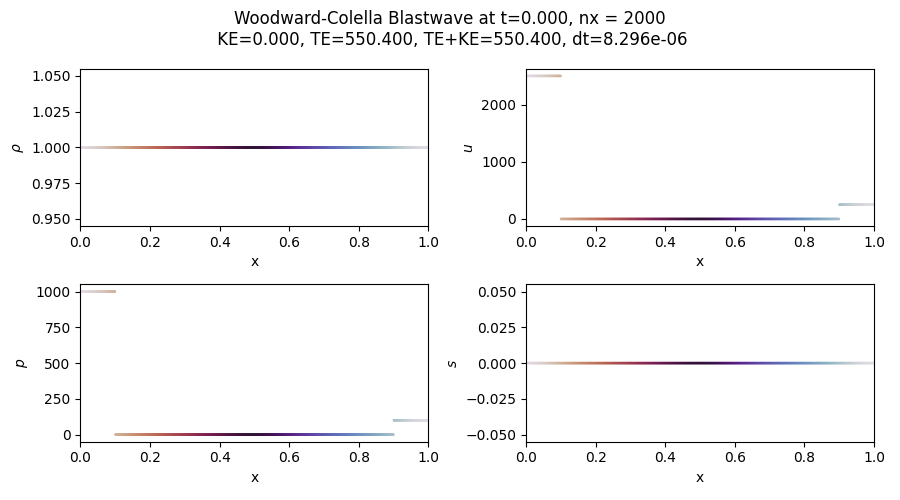

In [8]:
fig, axis = plt.subplots(2,2, figsize = (9, 5), squeeze = False)

plotState(fig, axis, runningState)

fig.tight_layout()

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
fig.savefig(f'{imagePath}/frame_{0:05d}.png')


In [9]:
from compressibleSPH.modules.timestep.compressible import computeTimestep


t_limit = timeLimit
# config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
config.cflFactor = 0.2

nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 20


config.minDt = 1e-8
trajectory = []

priorStep = None
t = 0
i = 0
tq = tqdm(total = 1000, leave = True)
while t < timeLimit:
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = schemeConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)
    t = result.state.t.item() if isinstance(result.state.t, torch.Tensor) else result.state.t
    tq.n = int(t / timeLimit * 1000)
    i = i + 1

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy
    config.dt = computeTimestep(runningState, config, schemeConfig, dt = config.dt) 
    
    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"{i:6d}: time: {t:8.4g}/{timeLimit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}, step time: {timing:.3f}ms, adaptive dt: {config.dt:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

    if i % 50 == 0 or i == nSteps - 1:
        plotState(fig, axis, runningState)
        # fig.tight_layout()
        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePath}/frame_{i:05d}.png')
        
    if i % 500 == 0:
        exportSimulationSystem(exportPath, f'state_{i:04d}', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
            'kineticEnergy': kineticEnergy,
            'thermalEnergy': thermalEnergy,
            'totalEnergy': totalEnergy,
            'frame_num': i,
        }))
        

Running with dt: 8.29648161015939e-06, which gives nSteps: 4580


  0%|          | 0/1000 [00:00<?, ?it/s]

Module compressibleSPH.modules.adaptiveSupport.wp_psi 8875fe6 load on device 'cuda:0' took 1.72 ms  (cached)
Module sphWarpCore.radiusSearch.wp_compactHash e67fccd load on device 'cuda:0' took 3.86 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_psi0 0564b5b load on device 'cuda:0' took 2.48 ms  (cached)
Module sphWarpCore.operations.wp_density 032287d load on device 'cuda:0' took 2.21 ms  (cached)
Module sphWarpCore.crk.crk_volume a999eca load on device 'cuda:0' took 4.78 ms  (cached)
Module sphWarpCore.crk.crk_moments eedc208 load on device 'cuda:0' took 2.86 ms  (cached)
Module sphWarpCore.crk.crk_density c8e8d13 load on device 'cuda:0' took 2.05 ms  (cached)
Module sphWarpCore.operations.wp_gradient 5b109d2 load on device 'cuda:0' took 4.80 ms  (cached)
Module compressibleSPH.modules.crk.accel 7ac821f load on device 'cuda:0' took 3.63 ms  (cached)
Module compressibleSPH.modules.crk.dudt 28189e6 load on device 'cuda:0' took 3.13 ms  (cached)
Module compressibleSPH.mod

In [10]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'kineticEnergy': kineticEnergy,
    'thermalEnergy': thermalEnergy,
    'totalEnergy': totalEnergy,
    'frame_num': i,
}))

In [11]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');